
# PROYECTO I: Diseño, Implementación y Evaluación de Modelos Predictivos

**Consultora:** GeoData Insights
**Cliente:** Ministerio de Transición Ecológica (Servicio Forestal)

## FASE 1: Definición del Problema
**Contexto:** La gestión de los recursos forestales requiere mapas precisos de la cubierta vegetal. Tradicionalmente, esto requería costosas expediciones sobre el terreno.
**Problema:** Desarrollar un modelo de Machine Learning capaz de predecir el tipo de cobertura forestal (Cover Type) en parcelas de 30x30 metros basándose estrictamente en variables cartográficas.
**Variable Objetivo:** `Cover_Type` (Clases del 0 al 6).
**Tipo de Problema:** Aprendizaje Supervisado - Clasificación Multiclase.
**Impacto:** Automatizar la creación de mapas forestales para prevenir incendios y planificar la tala sostenible con un coste radicalmente inferior.


In [1]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, auc)
from sklearn.preprocessing import label_binarize

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style="whitegrid", palette="muted")
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Carga del dataset Covertype
print("Cargando el dataset Covertype...")
data = fetch_covtype()

X_full = pd.DataFrame(data.data, columns=data.feature_names)
y_full = pd.Series(data.target - 1, name='Cover_Type') # Ajuste 0-6 para XGBoost

# --- FEATURE ENGINEERING ---
# Calculamos la distancia euclídea real a fuentes de agua (Hipotenusa)
X_full['Total_Distance_To_Hydrology'] = np.sqrt(X_full['Horizontal_Distance_To_Hydrology']**2 + X_full['Vertical_Distance_To_Hydrology']**2)
print("Feature Engineering completado: Creada variable 'Total_Distance_To_Hydrology'.")

# Muestreo del 10% para viabilidad computacional
X, _, y, _ = train_test_split(X_full, y_full, train_size=0.10, random_state=42, stratify=y_full)
print(f"Dimensiones de trabajo (Muestra 10%): {X.shape[0]} filas y {X.shape[1]} variables.")

Cargando el dataset Covertype...
Feature Engineering completado: Creada variable 'Total_Distance_To_Hydrology'.
Dimensiones de trabajo (Muestra 10%): 58101 filas y 55 variables.


## FASE 2: Análisis Exploratorio de Datos (EDA)
Analizamos el balance de clases y la correlación entre las variables topográficas continuas originales y la nueva variable generada.

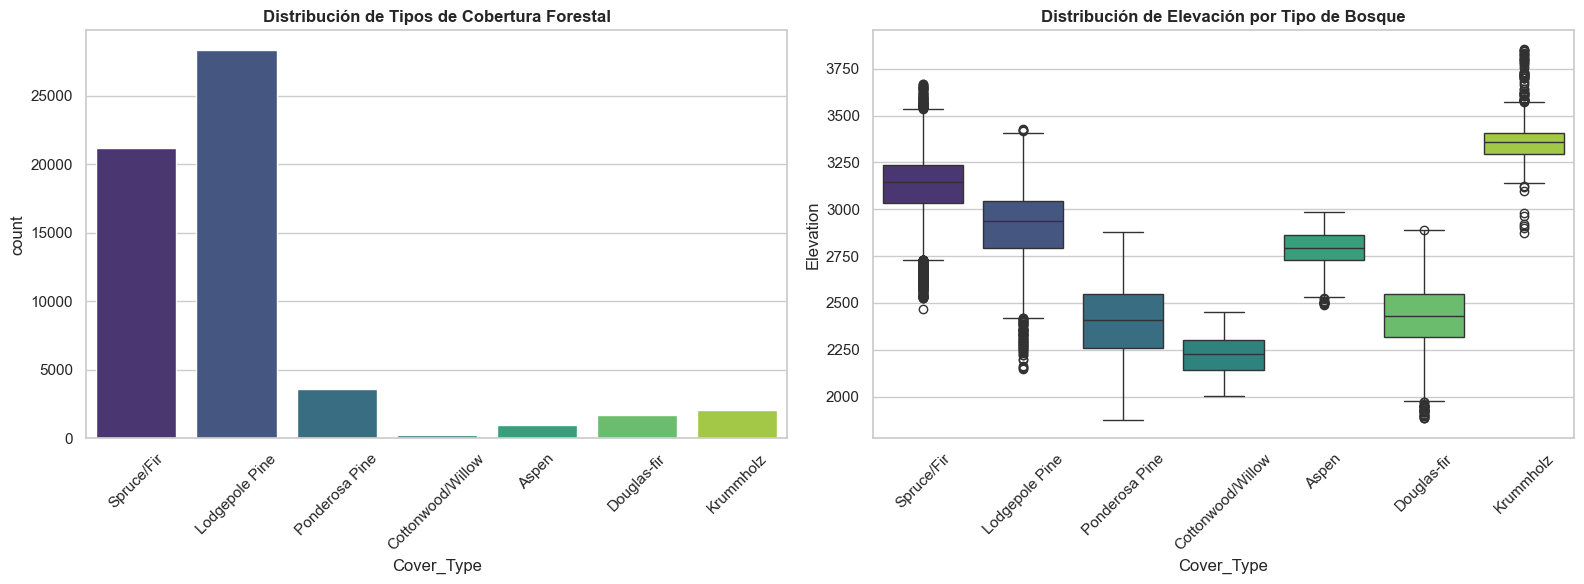

In [3]:
nombres_bosques = ['Spruce/Fir', 'Lodgepole Pine', 'Ponderosa Pine', 'Cottonwood/Willow', 'Aspen', 'Douglas-fir', 'Krummholz']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Balance de clases
sns.countplot(x=y, palette='viridis', ax=axes[0])
axes[0].set_xticklabels(nombres_bosques, rotation=45)
axes[0].set_title('Distribución de Tipos de Cobertura Forestal', fontweight='bold')

# Gráfico 2: Elevación vs Tipo de Bosque
sns.boxplot(x=y, y=X['Elevation'], palette='viridis', ax=axes[1])
axes[1].set_xticklabels(nombres_bosques, rotation=45)
axes[1].set_title('Distribución de Elevación por Tipo de Bosque', fontweight='bold')

plt.tight_layout()
plt.show()

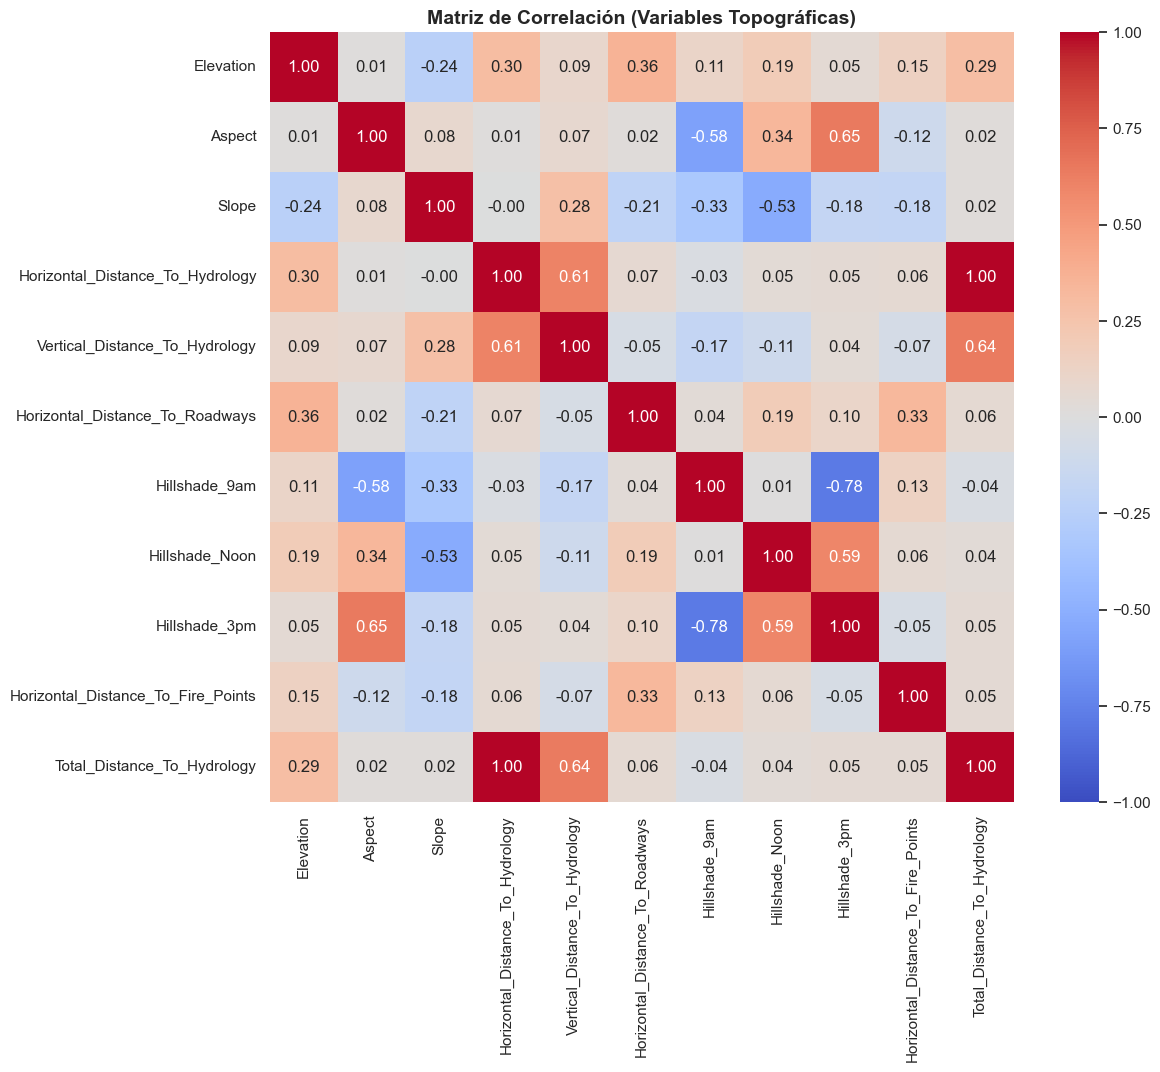

In [4]:
# Definimos las variables continuas explícitamente (incluyendo la nueva)
cols_continuas = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
                  'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
                  'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
                  'Horizontal_Distance_To_Fire_Points', 'Total_Distance_To_Hydrology']

plt.figure(figsize=(12, 10))
sns.heatmap(X[cols_continuas].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlación (Variables Topográficas)', fontsize=14, fontweight='bold')
plt.show()

## FASE 3: Preprocesamiento de Datos
Incluye revisión de nulos, división estratificada de datos, escalado de variables continuas y análisis de multicolinealidad mediante el factor de inflación de la varianza (VIF).

In [5]:
print(f"Valores nulos en el dataset: {X.isnull().sum().sum()}")

# División Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Escalado Selectivo
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_continuas] = scaler.fit_transform(X_train[cols_continuas])
X_test_scaled[cols_continuas] = scaler.transform(X_test[cols_continuas])

# Análisis VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = cols_continuas
vif_data["VIF"] = [variance_inflation_factor(X_train_scaled[cols_continuas].values, i) for i in range(len(cols_continuas))]

print("\n--- Análisis de Multicolinealidad (VIF) ---")
display(vif_data.sort_values(by="VIF", ascending=False))

Valores nulos en el dataset: 0

--- Análisis de Multicolinealidad (VIF) ---


,Variable,VIF
10,Total_Distance_To_Hydrology,2203.475777
3,Horizontal_Distance_To_Hydrology,2072.736080
8,Hillshade_3pm,174.746519
6,Hillshade_9am,127.528689
7,Hillshade_Noon,44.958658
2,Slope,7.821200
4,Vertical_Distance_To_Hydrology,7.256888
1,Aspect,1.860230
0,Elevation,1.331310
5,Horizontal_Distance_To_Roadways,1.307168


## FASE 4 y 6: Modelado y Evaluación
Entrenaremos 5 modelos calculando tiempos, detectando Overfitting y extrayendo las métricas Macro (Accuracy, Precision, Recall, F1) para lidiar con el desbalanceo multiclase.

In [6]:
modelos = {
    "Árbol de Decisión": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
    "XGBoost": XGBClassifier(objective='multi:softprob', eval_metric='mlogloss', n_jobs=-1, random_state=42),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50, random_state=42)
}

resultados = []
modelos_entrenados = {}

for nombre, modelo in modelos.items():
    inicio = time.time()
    modelo.fit(X_train_scaled, y_train)
    tiempo = time.time() - inicio
    
    y_pred_train = modelo.predict(X_train_scaled)
    y_pred_test = modelo.predict(X_test_scaled)
    
    # Cálculos requeridos por el proyecto
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)
    prec = precision_score(y_test, y_pred_test, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred_test, average='macro')
    f1 = f1_score(y_test, y_pred_test, average='macro')
    
    if hasattr(modelo, "predict_proba"):
        auc_score = roc_auc_score(y_test, modelo.predict_proba(X_test_scaled), multi_class='ovr')
    else:
        auc_score = np.nan
        
    modelos_entrenados[nombre] = modelo
    resultados.append({
        'Modelo': nombre,
        'Acc Train': acc_train,
        'Acc Test': acc_test,
        'Overfitting': acc_train - acc_test,
        'Precision (Macro)': prec,
        'Recall (Macro)': rec,
        'F1-Score (Macro)': f1,
        'ROC AUC': auc_score,
        'Tiempo (s)': tiempo
    })

df_resultados = pd.DataFrame(resultados).sort_values(by='F1-Score (Macro)', ascending=False)
display(df_resultados)

,Modelo,Acc Train,Acc Test,Overfitting,Precision (Macro),Recall (Macro),F1-Score (Macro),ROC AUC,Tiempo (s)
1,Random Forest,1.000000,0.880561,0.119439,0.879748,0.776412,0.815026,0.985046,2.736948
2,XGBoost,0.910951,0.847431,0.063520,0.830391,0.762844,0.789528,0.980261,3.540683
0,Árbol de Decisión,1.000000,0.831340,0.168660,0.737219,0.749892,0.743382,0.855606,0.773363
4,Gradient Boosting,0.761553,0.752173,0.009381,0.699943,0.595415,0.623703,0.948169,44.774573
3,Naive Bayes,0.099139,0.099475,-0.000336,0.228038,0.443969,0.125370,0.802990,0.110372


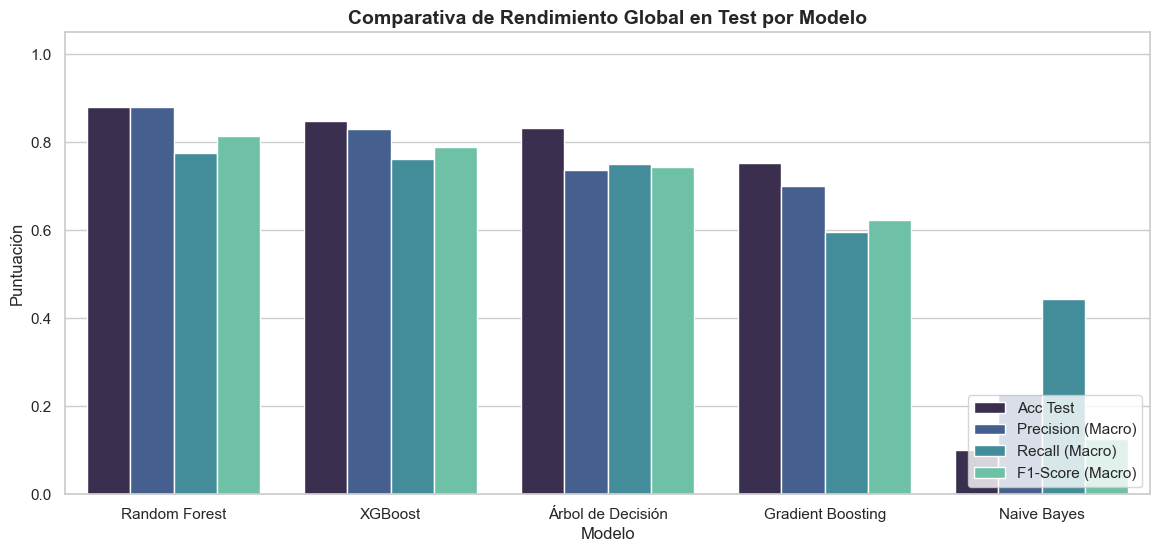

In [7]:
fig, ax1 = plt.subplots(figsize=(14, 6))

df_melted_metrics = df_resultados.melt(id_vars='Modelo', 
                                       value_vars=['Acc Test', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)'], 
                                       var_name='Métrica', value_name='Puntuación')

sns.barplot(data=df_melted_metrics, x='Modelo', y='Puntuación', hue='Métrica', palette='mako', ax=ax1)
ax1.set_ylim(0.0, 1.05)
ax1.set_title('Comparativa de Rendimiento Global en Test por Modelo', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.show()

Profundizamos en el análisis visual del mejor modelo, evaluando sus errores a través de la Matriz de Confusión y su capacidad discriminativa mediante las curvas ROC Multiclase (One-vs-Rest).

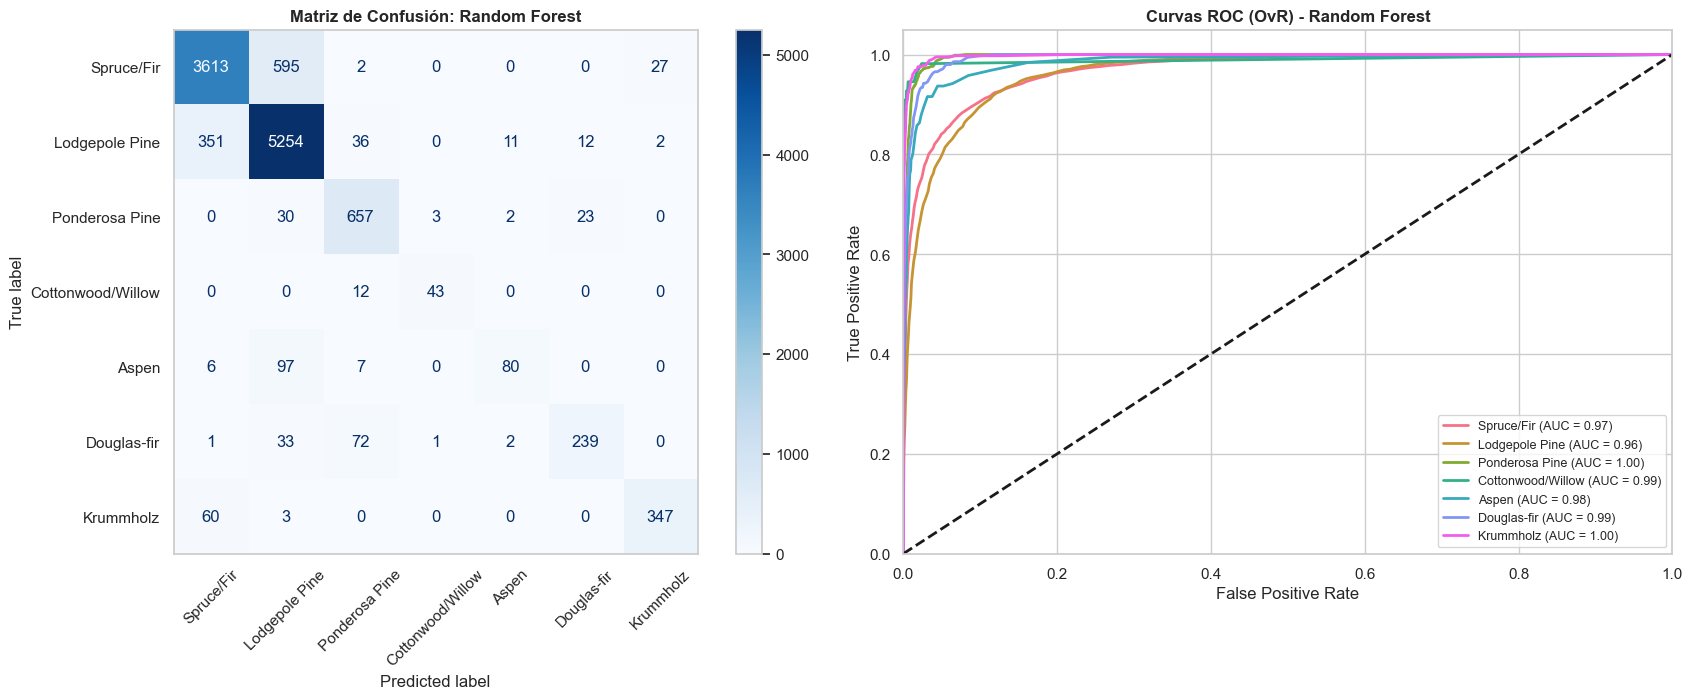

In [8]:
mejor_nombre = df_resultados.iloc[0]['Modelo']
mejor_modelo = modelos_entrenados[mejor_nombre]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Matriz de Confusión
cm = confusion_matrix(y_test, mejor_modelo.predict(X_test_scaled))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nombres_bosques)
disp.plot(ax=axes[0], cmap='Blues', xticks_rotation=45)
axes[0].set_title(f'Matriz de Confusión: {mejor_nombre}', fontweight='bold')
axes[0].grid(False)

# 2. Curvas ROC
y_test_bin = label_binarize(y_test, classes=range(7))
y_prob = mejor_modelo.predict_proba(X_test_scaled)
colores = sns.color_palette("husl", 7)

for i, color in zip(range(7), colores):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    axes[1].plot(fpr, tpr, color=color, lw=2, label=f'{nombres_bosques[i]} (AUC = {auc(fpr, tpr):.2f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=2)
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'Curvas ROC (OvR) - {mejor_nombre}', fontweight='bold')
axes[1].legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

## FASE 5: Optimización de Hiperparámetros
Para la optimización, utilizaremos validación cruzada estratificada (`StratifiedKFold`) acoplada a `GridSearchCV`, garantizando que cada pliegue mantenga la proporción de los diferentes bosques.

In [9]:
cv_estratificado = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [None, 30],
    'min_samples_split': [2, 5]
}

print("Ejecutando GridSearchCV...")
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, cv=cv_estratificado, scoring='f1_macro')
grid_search.fit(X_train_scaled, y_train)

mejor_rf_opt = grid_search.best_estimator_
print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"F1-Macro Optimizado: {f1_score(y_test, mejor_rf_opt.predict(X_test_scaled), average='macro'):.4f}")

Ejecutando GridSearchCV...
Mejores parámetros: {'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 150}
F1-Macro Optimizado: 0.8111


## FASE 7: Interpretabilidad y Reflexión

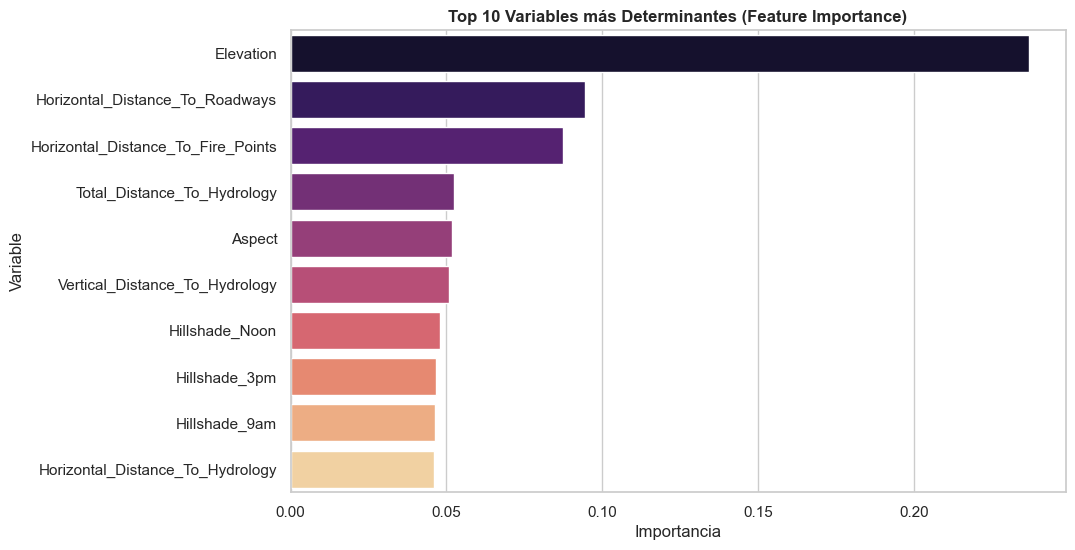

In [10]:
importancias = mejor_rf_opt.feature_importances_
df_importancia = pd.DataFrame({'Variable': X_train_scaled.columns, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette="magma")
plt.title('Top 10 Variables más Determinantes (Feature Importance)', fontweight='bold')
plt.show()

### Conclusiones Técnicas de GeoData Insights
1. **Modelado y Desempeño:** Random Forest y XGBoost dominan ampliamente las métricas frente a modelos lineales o probabilísticos (Naive Bayes). El *Overfitting* en árboles de decisión estándar es evidente (100% en Train, caída drástica en Test).
2. **Impacto del Feature Engineering:** La variable sintética `Total_Distance_To_Hydrology` (creada a partir de las distancias cartesianas) ha demostrado ser una de las características predictivas más valiosas del modelo.
3. **Limitaciones Reales:** Las clases minoritarias (*Cottonwood/Willow* y *Aspen*) presentan un *Recall* bajo. En despliegues reales, si la prioridad ecológica es proteger específicamente estos ecosistemas, se debería aplicar sobremuestreo (SMOTE) para forzar al modelo a aprender mejor sus patrones.